# Chapter 1: Unsupervised Learning in the Machine Learning Ecosystem

**Book:** *Hands-On Unsupervised Learning Using Python* — Ankur A. Patel (O'Reilly, 2019)  
**Audience:** Beginners  
**Goal:** Understand key concepts, terms, and see simple Python examples for every major idea in Chapter 1.

---

## What you will learn

1. What machine learning is and where unsupervised learning fits
2. Supervised vs. unsupervised learning (with examples)
3. Strengths and weaknesses of each approach
4. Six ways unsupervised learning helps supervised projects
5. Overview of supervised algorithms (linear, neighborhood, tree-based)
6. Overview of unsupervised algorithms (dimensionality reduction, clustering, deep learning)
7. Real-world applications: anomaly detection and group segmentation

## Setup — run this cell first

We use common Python libraries that beginners typically install with Anaconda:

| Library | Purpose |
|---------|--------|
| **NumPy** | Math on arrays |
| **Pandas** | Tables / DataFrames |
| **Matplotlib** | Plots and charts |
| **scikit-learn** | Machine learning algorithms |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_blobs, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, mean_squared_error

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

from IPython.display import display
print("Libraries loaded successfully.")

Libraries loaded successfully.


---

## 1. The Machine Learning Ecosystem

### What is Machine Learning (ML)?

**Machine learning** is a branch of artificial intelligence where a computer **learns patterns from data** instead of being explicitly programmed with fixed rules.

**Example (non-ML):**  
`if temperature > 38°C → fever`  ← a human writes the rule.

**Example (ML):**  
Show the computer thousands of patient records → it learns which combinations of symptoms predict fever.

### Three main types of learning

| Type | Data has labels? | Question answered | Chapter 1 example |
|------|------------------|-------------------|-------------------|
| **Supervised** | Yes | "Given X, predict Y" | Predict flower species from measurements |
| **Unsupervised** | No | "What structure is hidden in X?" | Find natural groups of flowers without species names |
| **Reinforcement** | Reward signal | "What action maximizes reward?" | Game-playing AI (mentioned in book preface) |

> **This course focuses on unsupervised learning** — learning from data **without** correct answers provided.

---

## 2. Supervised vs. Unsupervised Learning

### Key terms

| Term | Definition | Beginner analogy |
|------|------------|------------------|
| **Feature (X)** | Input variables used to make predictions | Exam questions |
| **Label (Y)** | Correct answer we want to predict | Answer key |
| **Training** | Feeding data to a model so it learns | Studying with answer key |
| **Model** | The learned mathematical pattern | Your brain after studying |
| **Inference / Prediction** | Using the model on new data | Taking the real exam |
| **Labeled data** | Data where Y is known | Homework with solutions |
| **Unlabeled data** | Data where Y is unknown | A pile of photos with no captions |

### Side-by-side comparison

| | Supervised | Unsupervised |
|--|-----------|--------------|
| **Labels needed?** | Yes | No |
| **Main goal** | Predict an output | Discover structure |
| **Typical tasks** | Classification, regression | Clustering, dimensionality reduction |
| **Evaluation** | Compare prediction to true label | Harder — often needs human judgment |
| **Example** | Spam vs. not spam | Customer segments |

### Example A — Supervised Learning (classification)

We use the famous **Iris dataset**: measurements of iris flowers where the **species (label)** is known.

- **Features (X):** sepal length, sepal width, petal length, petal width  
- **Label (Y):** species name (setosa, versicolor, virginica)

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df_iris = pd.DataFrame(X, columns=feature_names)
df_iris["species"] = [target_names[i] for i in y]

print("Supervised dataset preview (labels ARE included):")
display(df_iris.head())
print(f"\nShape: {X.shape[0]} samples, {X.shape[1]} features, {len(target_names)} classes")

Supervised dataset preview (labels ARE included):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Shape: 150 samples, 4 features, 3 classes


In [3]:
# Train a simple supervised model: Logistic Regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)  # model learns from features AND labels
y_pred = clf.predict(X_test)

print(f"Supervised accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("The model was trained WITH labels — that is supervised learning.")

Supervised accuracy: 100.00%
The model was trained WITH labels — that is supervised learning.


### Example B — Unsupervised Learning (clustering)

Same iris measurements, but we **pretend we do not know the species**.  
Can the algorithm find groups on its own?

Unsupervised result — algorithm invented its own group IDs (0, 1, 2):


,petal length (cm),petal width (cm),species,cluster
0,1.4,0.2,setosa,1
1,1.4,0.2,setosa,1
2,1.3,0.2,setosa,1
3,1.5,0.2,setosa,1
4,1.4,0.2,setosa,1
5,1.7,0.4,setosa,1
6,1.4,0.3,setosa,1
7,1.5,0.2,setosa,1
8,1.4,0.2,setosa,1
9,1.5,0.1,setosa,1


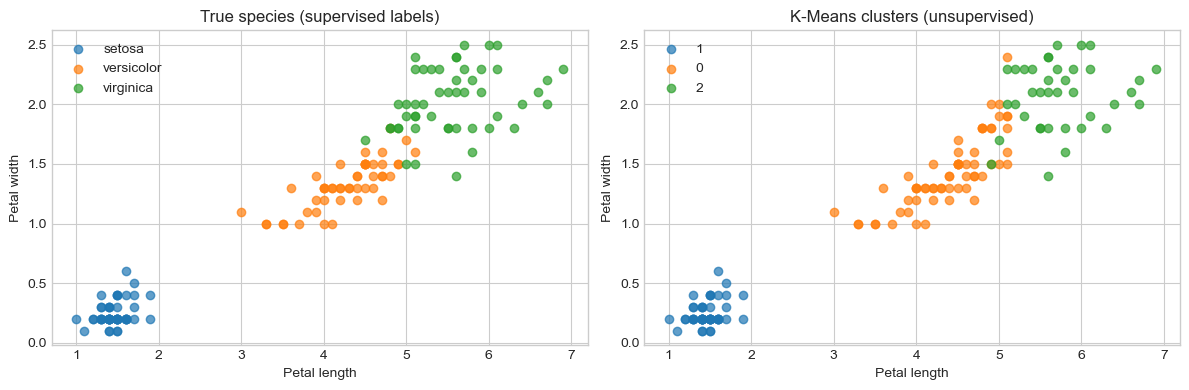

In [4]:
# Unsupervised: only use X, never pass y to fit()
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

df_iris["cluster"] = clusters
print("Unsupervised result — algorithm invented its own group IDs (0, 1, 2):")
display(df_iris[["petal length (cm)", "petal width (cm)", "species", "cluster"]].head(10))

# Visualize: clusters vs. true species
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, ax, color_col in [("True species (supervised labels)", axes[0], "species"),
                             ("K-Means clusters (unsupervised)", axes[1], "cluster")]:
    for group in df_iris[color_col].unique():
        subset = df_iris[df_iris[color_col] == group]
        ax.scatter(subset["petal length (cm)"], subset["petal width (cm)"], label=str(group), alpha=0.7)
    ax.set_xlabel("Petal length")
    ax.set_ylabel("Petal width")
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

**Takeaway:** Unsupervised learning found 3 groups that roughly match the 3 species — **without ever seeing species names** during training.

---

## 3. Strengths and Weaknesses

### Supervised Learning

| Strengths | Weaknesses |
|-----------|------------|
| Clear goal: minimize prediction error | Needs lots of **labeled** data (expensive to create) |
| Easy to measure performance (accuracy, RMSE) | Can **overfit** (memorize training data) |
| Works well when labels are reliable | Struggles when data changes over time (**data drift**) |
| Mature, well-understood algorithms | High-dimensional data needs careful feature work |

### Unsupervised Learning

| Strengths | Weaknesses |
|-----------|------------|
| Works on **unlabeled** data (most real-world data!) | No single "correct answer" to compare against |
| Discovers hidden patterns humans might miss | Results can be hard to interpret |
| Helps with preprocessing (PCA, feature learning) | Must choose parameters (e.g., number of clusters) |
| Enables anomaly detection and segmentation | Evaluation is often subjective |

### Key terms

| Term | Meaning |
|------|--------|
| **Overfitting** | Model memorizes training data but fails on new data |
| **Underfitting** | Model is too simple to capture real patterns |
| **Generalization** | Performing well on unseen data |
| **Data drift** | Data distribution changes over time (e.g., new fraud patterns) |

In [5]:
# Demo: Overfitting with a very deep decision tree
X_small, y_small = X[:40], y[:40]  # tiny training set

tree_simple = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_overfit = DecisionTreeClassifier(max_depth=None, random_state=42)  # no limit

for name, model in [("Simple tree (depth=2)", tree_simple), ("Deep tree (overfitting risk)", tree_overfit)]:
    model.fit(X_small, y_small)
    train_acc = accuracy_score(y_small, model.predict(X_small))
    test_acc = accuracy_score(y, model.predict(X))
    print(f"{name}: train={train_acc:.0%}, test={test_acc:.0%}")

Simple tree (depth=2): train=100%, test=33%
Deep tree (overfitting risk): train=100%, test=33%


---

## 4. How Unsupervised Learning Improves Supervised Solutions

Chapter 1 explains **six problems** where unsupervised methods help:

| Problem | What it means | Unsupervised help |
|---------|---------------|-------------------|
| **1. Insufficient labeled data** | Not enough examples with answers | Cluster or pre-train on large unlabeled data |
| **2. Overfitting** | Model too complex for data size | Dimensionality reduction, regularization via fewer features |
| **3. Curse of dimensionality** | Too many features; data becomes sparse | PCA, feature selection |
| **4. Feature engineering** | Creating useful inputs is hard | Autoencoders learn features automatically (Ch. 7–8) |
| **5. Outliers** | Rare unusual points | Anomaly detection flags them (Ch. 4) |
| **6. Data drift** | Patterns change over time | Monitor clusters/distributions for shifts |

### 4.1 Curse of Dimensionality — PCA demo

**Curse of dimensionality:** As features increase, data points spread out in high-dimensional space and become hard to compare.

**PCA (Principal Component Analysis):** An unsupervised technique that compresses many features into fewer while keeping most information.

Original features: 4
Reduced to: 2 principal components
Variance retained: 95.8%


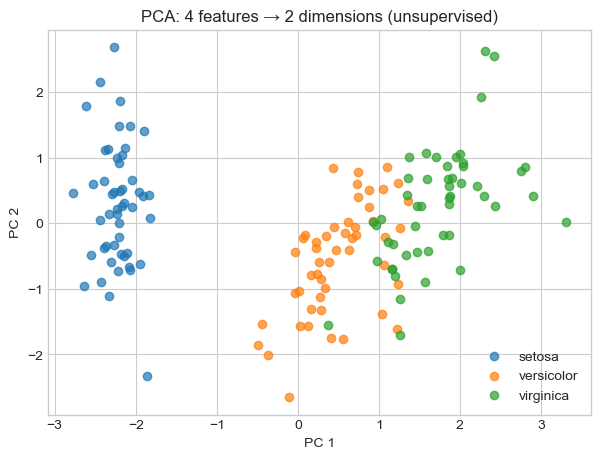

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

print(f"Original features: {X.shape[1]}")
print(f"Reduced to: {X_2d.shape[1]} principal components")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(7, 5))
for i, species in enumerate(target_names):
    mask = y == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=species, alpha=0.7)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA: 4 features → 2 dimensions (unsupervised)")
plt.legend()
plt.show()

### 4.2 Outliers — simple anomaly detection idea

An **outlier** is a data point very different from the majority. Unsupervised methods can flag them without labeled "fraud" examples.

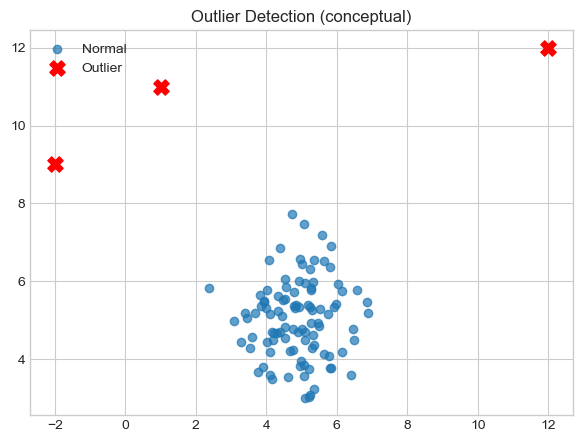

Detected 3 outliers out of 103 points


In [7]:
np.random.seed(42)
normal = np.random.normal(loc=5, scale=1, size=(100, 2))
outliers = np.array([[12, 12], [1, 11], [-2, 9]])
data = np.vstack([normal, outliers])

# Simple rule: flag points far from the mean (Z-score > 2)
z_scores = np.abs((data - data.mean(axis=0)) / data.std(axis=0))
is_outlier = z_scores.max(axis=1) > 2

plt.figure(figsize=(7, 5))
plt.scatter(data[~is_outlier, 0], data[~is_outlier, 1], label="Normal", alpha=0.7)
plt.scatter(data[is_outlier, 0], data[is_outlier, 1], label="Outlier", color="red", s=120, marker="X")
plt.title("Outlier Detection (conceptual)")
plt.legend()
plt.show()
print(f"Detected {is_outlier.sum()} outliers out of {len(data)} points")

---

## 5. Supervised Algorithms (Chapter 1 Overview)

The book groups supervised algorithms into three families. Below: what each does + a tiny example.

### 5.1 Linear Methods

| Algorithm | Task | Idea |
|-----------|------|------|
| **Linear Regression** | Predict a number | Fit a straight line: y = mx + b |
| **Logistic Regression** | Classify into categories | Fit a curve that outputs probabilities |

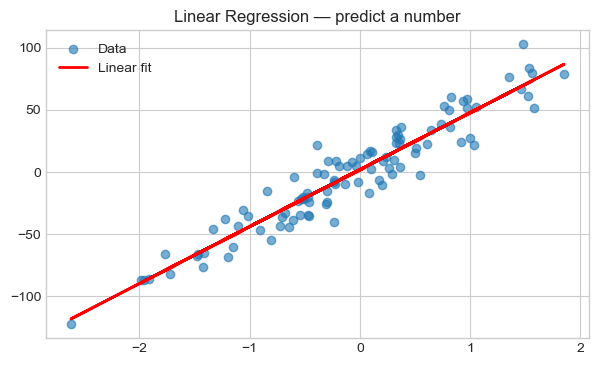

RMSE: 13.25


In [8]:
# Linear Regression — predict a continuous value
X_reg, y_reg = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)

lr = LinearRegression()
lr.fit(X_reg, y_reg)
y_reg_pred = lr.predict(X_reg)

plt.figure(figsize=(7, 4))
plt.scatter(X_reg, y_reg, alpha=0.6, label="Data")
plt.plot(X_reg, y_reg_pred, color="red", linewidth=2, label="Linear fit")
plt.title("Linear Regression — predict a number")
plt.legend()
plt.show()
rmse = np.sqrt(mean_squared_error(y_reg, y_reg_pred))
print(f"RMSE: {rmse:.2f}")

In [9]:
# Logistic Regression — classify iris species
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)
print(f"Logistic Regression accuracy: {accuracy_score(y_test, log_reg.predict(X_test)):.2%}")

Logistic Regression accuracy: 100.00%


### 5.2 Neighborhood-Based Methods

| Algorithm | Idea |
|-----------|------|
| **k-Nearest Neighbors (k-NN)** | Classify a point by majority vote of its k closest neighbors |

**Key term — distance metric:** How "close" two points are (usually Euclidean distance).

In [10]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print(f"k-NN (k=5) accuracy: {accuracy_score(y_test, knn.predict(X_test)):.2%}")

k-NN (k=5) accuracy: 100.00%


### 5.3 Tree-Based Methods

| Algorithm | Idea |
|-----------|------|
| **Decision Tree** | Ask yes/no questions to split data (like a flowchart) |
| **Bagging** | Train many trees on random subsets, average votes |
| **Random Forest** | Bagging + random feature subsets at each split |
| **Boosting** | Train trees sequentially; each fixes previous errors |

**Key terms:**
- **Ensemble:** Combining multiple models for better results
- **Hyperparameter:** A setting you choose before training (e.g., tree depth, k in k-NN)

In [11]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Bagging": BaggingClassifier(DecisionTreeClassifier(), n_estimators=25, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=25, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42),
}

print("Supervised algorithm comparison (Iris dataset):")
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"  {name:20s} → {acc:.2%}")

Supervised algorithm comparison (Iris dataset):
  Decision Tree        → 100.00%
  Bagging              → 100.00%
  Random Forest        → 100.00%
  Gradient Boosting    → 100.00%


---

## 6. Unsupervised Algorithms (Chapter 1 Overview)

The book organizes unsupervised methods into four categories. We preview each with terms and a simple demo where possible.

### 6.1 Dimensionality Reduction

Reduce the number of features while keeping structure.

| Method | Type | Idea |
|--------|------|------|
| **PCA** | Linear projection | Find directions of maximum variance |
| **SVD** | Linear algebra | Matrix factorization (related to PCA) |
| **Random Projection** | Linear | Fast approximate reduction using random matrices |
| **Isomap** | Manifold learning | Preserve geodesic distances on curved surfaces |
| **t-SNE** | Manifold learning | Great for 2D visualization of clusters |
| **Dictionary Learning** | Sparse coding | Represent data as combinations of basis patterns |

**Key terms:**
- **Linear projection:** Flatten data onto straight directions
- **Manifold learning:** Data lies on a curved lower-dimensional surface embedded in high-D space

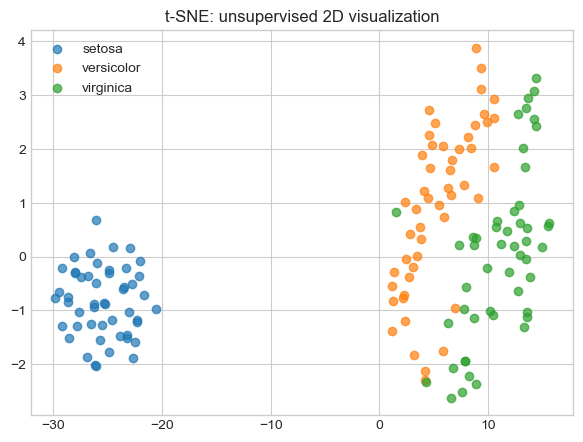

In [12]:
# t-SNE visualization (popular for exploring clusters visually)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
for i, species in enumerate(target_names):
    mask = y == i
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=species, alpha=0.7)
plt.title("t-SNE: unsupervised 2D visualization")
plt.legend()
plt.show()

### 6.2 Clustering

Group similar data points together.

| Algorithm | Idea | Key term |
|-----------|------|----------|
| **k-Means** | Partition into k groups around centroids | **Centroid:** center of a cluster |
| **Hierarchical Clustering** | Build a tree of nested clusters | **Dendrogram:** tree diagram of merges |
| **DBSCAN** | Dense regions = clusters; sparse = noise | **Density-based:** shape-flexible clustering |

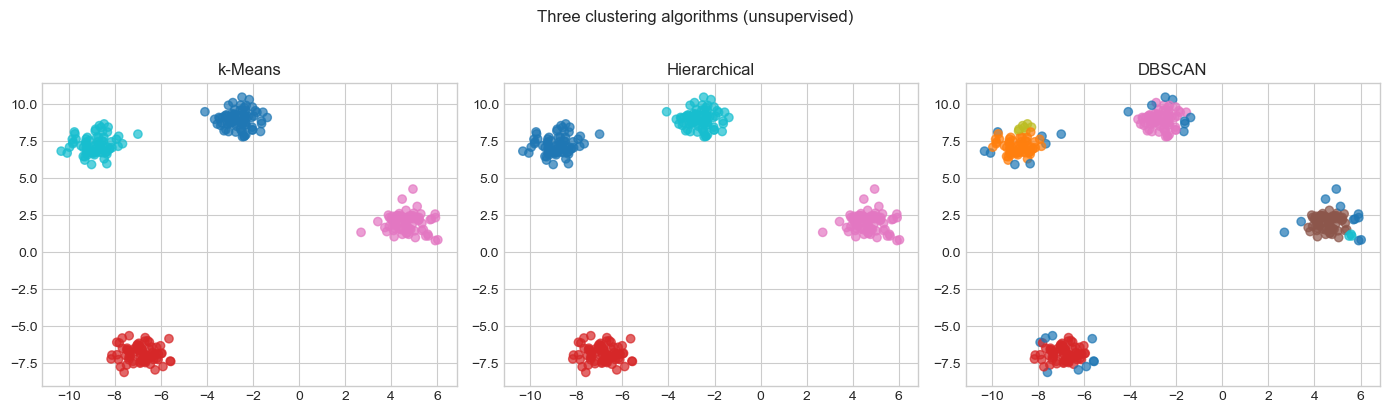

In [13]:
X_blob, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, model, title in [
    (axes[0], KMeans(n_clusters=4, random_state=42, n_init=10), "k-Means"),
    (axes[1], AgglomerativeClustering(n_clusters=4), "Hierarchical"),
    (axes[2], DBSCAN(eps=0.4, min_samples=5), "DBSCAN"),
]:
    labels = model.fit_predict(X_blob)
    ax.scatter(X_blob[:, 0], X_blob[:, 1], c=labels, cmap="tab10", alpha=0.7)
    ax.set_title(title)

plt.suptitle("Three clustering algorithms (unsupervised)", y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Feature Extraction

| Method | Idea |
|--------|------|
| **Autoencoder** | Neural network that compresses input and reconstructs it — the compressed layer becomes new features |
| **Supervised feedforward network** | Can also learn features, but needs labels |

> **Autoencoders** are covered hands-on in Chapters 7–8. Think of them as a "data zipper": compress → learn → unzip.

### 6.4 Unsupervised Deep Learning

Advanced neural network methods introduced in later chapters:

| Method | Abbreviation | Purpose |
|--------|--------------|--------|
| **Unsupervised pretraining** | — | Train layers on unlabeled data before fine-tuning with labels |
| **Restricted Boltzmann Machine** | RBM | Learn patterns; used in recommender systems (Ch. 10) |
| **Deep Belief Network** | DBN | Stack RBMs for hierarchical feature learning (Ch. 11) |
| **Generative Adversarial Network** | GAN | Generator creates fake data; discriminator tries to detect fakes (Ch. 12) |

**Key term — generative model:** A model that can **create new data** similar to what it learned.

---

## 7. Successful Applications (Chapter 1)

### 7.1 Anomaly Detection

Find rare events that differ from normal behavior.

**Examples:** Credit card fraud, network intrusions, equipment failure, disease outbreaks.

**Why unsupervised?** Fraud is rare — we often lack enough labeled fraud examples.

### 7.2 Group Segmentation

Divide users/customers into distinct groups based on behavior — **without** predefined categories.

**Examples:**
- Marketing: budget shoppers vs. premium buyers
- Lending: borrower risk profiles (Chapter 6 uses Lending Club data)
- Streaming: music/movie taste clusters

**Key terms:**
- **Segment:** A group of similar users
- **Homogeneous:** Members within a group are alike
- **Distinct:** Groups are different from each other

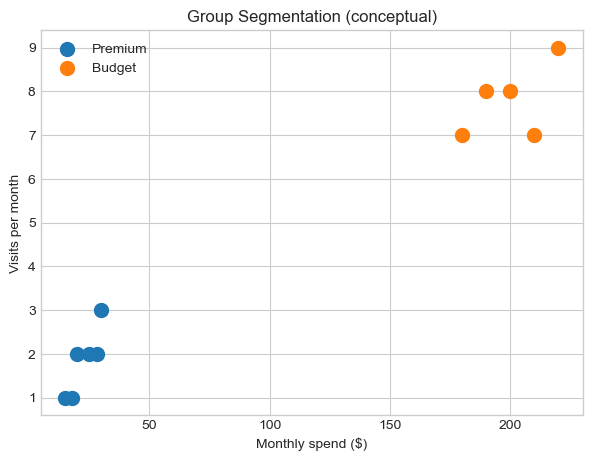

,monthly_spend,visits_per_month,segment,segment_label
0,25,2,1,Premium
1,30,3,1,Premium
2,28,2,1,Premium
3,200,8,0,Budget
4,180,7,0,Budget
5,220,9,0,Budget
6,15,1,1,Premium
7,20,2,1,Premium
8,18,1,1,Premium
9,190,8,0,Budget


In [14]:
# Conceptual customer segmentation with synthetic data
customers = pd.DataFrame({
    "monthly_spend": [25, 30, 28, 200, 180, 220, 15, 20, 18, 190, 210],
    "visits_per_month": [2, 3, 2, 8, 7, 9, 1, 2, 1, 8, 7],
})

seg = KMeans(n_clusters=2, random_state=42, n_init=10)
customers["segment"] = seg.fit_predict(customers)
customers["segment_label"] = customers["segment"].map({0: "Budget", 1: "Premium"})

plt.figure(figsize=(7, 5))
for label in customers["segment_label"].unique():
    subset = customers[customers["segment_label"] == label]
    plt.scatter(subset["monthly_spend"], subset["visits_per_month"], label=label, s=100)
plt.xlabel("Monthly spend ($)")
plt.ylabel("Visits per month")
plt.title("Group Segmentation (conceptual)")
plt.legend()
plt.show()

display(customers)

---

## 8. Glossary — All Chapter 1 Terms

| Term | One-line definition |
|------|---------------------|
| **Supervised learning** | Learn from labeled data to predict outputs |
| **Unsupervised learning** | Find patterns in unlabeled data |
| **Reinforcement learning** | Learn actions via rewards and penalties |
| **Feature** | Input variable (column in your dataset) |
| **Label** | Target variable (the answer) |
| **Classification** | Predict a category |
| **Regression** | Predict a number |
| **Clustering** | Group similar points without labels |
| **Dimensionality reduction** | Reduce number of features |
| **PCA** | Principal Component Analysis — linear dimensionality reduction |
| **Manifold learning** | Nonlinear dimensionality reduction (t-SNE, Isomap) |
| **Overfitting** | Model memorizes training data |
| **Curse of dimensionality** | High dimensions make data sparse and hard to compare |
| **Feature engineering** | Creating useful input features |
| **Outlier / Anomaly** | Unusual data point |
| **Data drift** | Data distribution changes over time |
| **k-Means** | Clustering by k centroids |
| **DBSCAN** | Density-based clustering |
| **Autoencoder** | Neural network for compression and feature learning |
| **RBM / DBN / GAN** | Deep unsupervised neural architectures |
| **Anomaly detection** | Finding rare unusual events |
| **Group segmentation** | Dividing users into behavioral clusters |
| **Ensemble** | Combining multiple models |
| **Hyperparameter** | Model setting chosen before training |

---

## 9. Chapter 1 Summary

```
Machine Learning
├── Supervised (has labels)     → predict Y from X
├── Unsupervised (no labels)    → discover structure in X  ← THIS COURSE
└── Reinforcement (rewards)     → learn optimal actions

Unsupervised helps supervised when:
  • not enough labels  • overfitting  • too many features
  • hard feature engineering  • outliers  • data drift

Main unsupervised tasks:
  • Clustering (k-Means, DBSCAN, hierarchical)
  • Dimensionality reduction (PCA, t-SNE)
  • Feature extraction (autoencoders)
  • Deep unsupervised (RBM, DBN, GAN)

Key applications:
  • Anomaly detection (fraud, failures)
  • Group segmentation (customers, borrowers)
```

### What's next?

**Chapter 2** walks through a complete end-to-end supervised ML project (environment setup, data prep, model training, evaluation, and ensembling). That project framework will be reused throughout the book.

---

### Practice questions

1. You have 1 million emails but only 500 are labeled spam/not-spam. Is this a supervised or unsupervised problem? How could both approaches help?
2. Why might PCA help before training a classifier on data with 500 features?
3. Name one business use case for clustering and one for anomaly detection.
4. What is the difference between a **feature** and a **label**?
5. Why is evaluating unsupervised models harder than supervised ones?